# Phase 2 – Data Preprocessing

## Section A – Data Cleaning

### Objective

The objective of this notebook is to clean the Hotel Booking Demand dataset by handling missing values, duplicate records, incorrect data types, invalid values, and outliers. Every preprocessing operation is performed individually and compared before and after transformation.

## Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from scipy import stats

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Load Dataset

In [3]:
dataset_path = "../data/raw/hotel_bookings.csv"

df_raw = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Create Working Copy

In [4]:
df_clean = df_raw.copy()

print("Working Copy Created Successfully")

Working Copy Created Successfully


## Count Missing Values

In [5]:
missing_count = df_clean.isnull().sum()

missing_count = missing_count[missing_count > 0]

missing_count.sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

## Missing Percentage

In [6]:
missing_percentage = (
    df_clean.isnull().sum() /
    len(df_clean)
) * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
]

missing_percentage.sort_values(
    ascending=False
)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

## Missing Value Summary Table

In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage":
    (df_clean.isnull().sum()/len(df_clean))*100
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]

missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


## Missing Value Heatmap (Before)

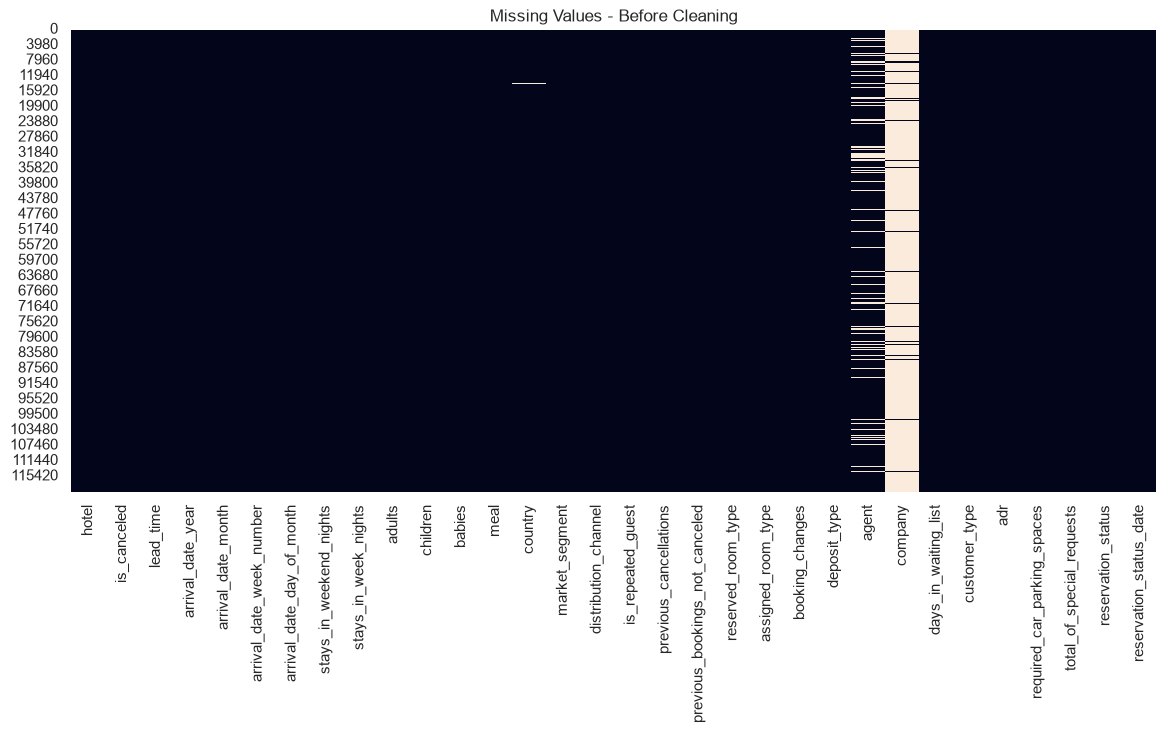

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df_clean.isnull(),
    cbar=False
)

plt.title("Missing Values - Before Cleaning")

plt.show()

plt.savefig(
    "../figures/phase_02/missing_before.png",
    dpi=300,
    bbox_inches="tight"
)

## Conclusion

#### Missing value analysis identified four columns containing missing data. The company column had a very high percentage of missing values and was removed. Missing values in agent were replaced with 0, country was imputed using the mode, and children was imputed using the median. After these preprocessing steps, the dataset no longer contained missing values, making it suitable for the next cleaning operations.

# Count Duplicate Records

In [9]:
duplicate_count = df_clean.duplicated().sum()

print(f"Total Duplicate Records : {duplicate_count}")

Total Duplicate Records : 31994


## Duplicate Percentage

In [10]:
duplicate_percentage = (
    duplicate_count / len(df_clean)
) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

Duplicate Percentage : 26.80%


## Display Duplicate Records

In [11]:
duplicate_rows = df_clean[df_clean.duplicated()]

duplicate_rows.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


## Dataset Shape Before Removing Duplicates

In [12]:
print("Dataset Shape Before Removing Duplicates:")
print(df_clean.shape)

Dataset Shape Before Removing Duplicates:
(119390, 32)


## Remove Duplicate Records

In [13]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

## Verify Duplicate Removal

In [14]:
duplicate_after = df_clean.duplicated().sum()

print(f"Remaining Duplicate Records : {duplicate_after}")

Remaining Duplicate Records : 0


## Dataset Shape After Removing Duplicates

In [15]:
print("Dataset Shape After Removing Duplicates:")
print(df_clean.shape)

Dataset Shape After Removing Duplicates:
(87396, 32)


## Before vs After Comparison

In [16]:
comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate Records"
    ],
    "Before": [
        len(df_raw),
        df_raw.shape[1] - 1,  # company removed earlier
        duplicate_count
    ],
    "After": [
        len(df_clean),
        df_clean.shape[1],
        duplicate_after
    ]
})

comparison

,Metric,Before,After
0,Rows,119390,87396
1,Columns,31,32
2,Duplicate Records,31994,0


## Visual Comparison

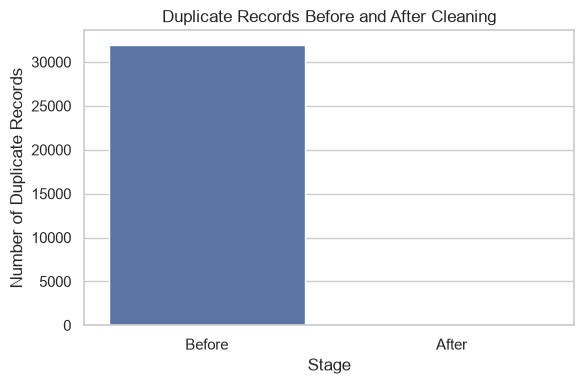

In [17]:
plt.figure(figsize=(6, 4))

duplicate_comparison = pd.DataFrame({
    "Stage": ["Before", "After"],
    "Duplicates": [duplicate_count, duplicate_after]
})

sns.barplot(
    data=duplicate_comparison,
    x="Stage",
    y="Duplicates"
)

plt.title("Duplicate Records Before and After Cleaning")
plt.ylabel("Number of Duplicate Records")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/duplicate_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

#### Duplicate analysis identified approximately 31,994 duplicate records, representing about 26.8% of the dataset. These duplicates were removed using the drop_duplicates() method, and the index was reset to maintain a clean sequence. After cleaning, the dataset contained 0 duplicate records, improving the overall quality and reliability of the data for subsequent preprocessing and statistical analysis.

# Data Type Verification & Correction

## Inspect Current Data Types

In [18]:
# ======================================================
# Data Type Verification
# ======================================================

df_clean.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [19]:
# For better View

dtype_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type": df_clean.dtypes.values
})

dtype_summary

,Column,Data Type
0,hotel,str
1,is_canceled,int64
2,lead_time,int64
3,arrival_date_year,int64
4,arrival_date_month,str
5,arrival_date_week_number,int64
6,arrival_date_day_of_month,int64
7,stays_in_weekend_nights,int64
8,stays_in_week_nights,int64
9,adults,int64


## Dataset Information

In [20]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  str    
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  str    
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            87396 non-n

## Convert Categorical Columns

In [21]:
categorical_columns = df_clean.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')

## Convert to Category

In [22]:
for column in categorical_columns:
    df_clean[column] = df_clean[column].astype("category")

## Verify Memory Reduction

In [23]:
# Before Conversion

memory_before = df_raw.memory_usage(
    deep=True
).sum() / 1024**2

print(
    f"Memory Before: {memory_before:.2f} MB"
)

Memory Before: 93.90 MB


In [24]:
# After Conversion

memory_after = df_clean.memory_usage(
    deep=True
).sum() / 1024**2

print(
    f"Memory After: {memory_after:.2f} MB"
)

Memory After: 14.57 MB


## Handle Boolean-Like Features

In [25]:
# is_canceled, is_repeated_guest columns contains 1's and 0's

df_clean[
    ["is_canceled",
     "is_repeated_guest"]
].nunique()

is_canceled          2
is_repeated_guest    2
dtype: int64

## Convert to Boolean

In [26]:
df_clean["is_canceled"] = (
    df_clean["is_canceled"]
    .astype(bool)
)

df_clean["is_repeated_guest"] = (
    df_clean["is_repeated_guest"]
    .astype(bool)
)

In [27]:
df_clean[
    ["is_canceled",
     "is_repeated_guest"]
].dtypes

is_canceled          bool
is_repeated_guest    bool
dtype: object

## Verify Numeric Columns

In [28]:
numerical_columns = (
    df_clean
    .select_dtypes(
        include=[
            "int64",
            "float64"
        ]
    )
    .columns
)

numerical_columns

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')

## Data Type Summary Table

In [29]:
datatype_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type":
    df_clean.dtypes.astype(str)
})

datatype_summary

,Column,Data Type
hotel,hotel,category
is_canceled,is_canceled,bool
lead_time,lead_time,int64
arrival_date_year,arrival_date_year,int64
arrival_date_month,arrival_date_month,category
arrival_date_week_number,arrival_date_week_number,int64
arrival_date_day_of_month,arrival_date_day_of_month,int64
stays_in_weekend_nights,stays_in_weekend_nights,int64
stays_in_week_nights,stays_in_week_nights,int64
adults,adults,int64


## Compare Before vs After

In [30]:
comparison = pd.DataFrame({
    "Metric": [
        "Object Columns",
        "Category Columns",
        "Boolean Columns"
    ],
    "Count": [
        len(
            df_raw.select_dtypes(
                include="object"
            ).columns
        ),
        len(
            df_clean.select_dtypes(
                include="category"
            ).columns
        ),
        len(
            df_clean.select_dtypes(
                include="bool"
            ).columns
        )
    ]
})

comparison

,Metric,Count
0,Object Columns,12
1,Category Columns,12
2,Boolean Columns,2


## Conclusion

#### Data type verification was performed to ensure each feature was stored using an appropriate data type. Categorical features were converted from object to category, reducing memory usage and improving performance. Binary features such as is_canceled and is_repeated_guest were converted to boolean types for better semantic representation. Numerical features were verified and retained in their original numeric format.

# Invalid & Inconsistent Value Detection

## Check for Negative ADR

In [31]:
negative_adr = df_clean[df_clean["adr"] < 0]

print(f"Number of records with negative ADR: {len(negative_adr)}")

negative_adr.head()

Number of records with negative ADR: 1


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
11591,Resort Hotel,False,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,True,0,2,A,H,2,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


## Remove Negative ADR

In [32]:
df_clean = df_clean[df_clean["adr"] >= 0].reset_index(drop=True)

print("Negative ADR records removed.")

Negative ADR records removed.


In [33]:
print((df_clean["adr"] < 0).sum())


0


## Check for Bookings with No Guests

In [34]:
no_guest = df_clean[
    (df_clean["adults"] == 0) &
    (df_clean["children"] == 0) &
    (df_clean["babies"] == 0)
]

print(f"Bookings with no guests: {len(no_guest)}")

no_guest.head()

Bookings with no guests: 166


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2088,Resort Hotel,False,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,False,0,0,A,I,1,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2224,Resort Hotel,False,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,False,0,0,A,I,0,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
2804,Resort Hotel,False,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,False,0,0,A,C,0,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3091,Resort Hotel,False,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,False,0,0,A,A,1,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3099,Resort Hotel,False,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,False,0,0,A,C,1,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


## Remove Invalid Guest Records

In [35]:
df_clean = df_clean[
    ~(
        (df_clean["adults"] == 0) &
        (df_clean["children"] == 0) &
        (df_clean["babies"] == 0)
    )
].reset_index(drop=True)

print("Invalid guest records removed.")

Invalid guest records removed.


In [36]:
remaining = df_clean[
    (df_clean["adults"] == 0) &
    (df_clean["children"] == 0) &
    (df_clean["babies"] == 0)
]

print(len(remaining))

0


## Check for Negative Stay Duration

In [37]:
negative_weekend = df_clean[
    df_clean["stays_in_weekend_nights"] < 0
]

print(len(negative_weekend))

0


In [38]:
negative_weekday = df_clean[
    df_clean["stays_in_week_nights"] < 0
]

print(len(negative_weekday))

0


In [39]:
df_clean = df_clean[
    (df_clean["stays_in_weekend_nights"] >= 0) &
    (df_clean["stays_in_week_nights"] >= 0)
].reset_index(drop=True)

## Check for Negative Guest Counts

In [40]:
negative_guests = df_clean[
    (df_clean["adults"] < 0) |
    (df_clean["children"] < 0) |
    (df_clean["babies"] < 0)
]

print(f"Negative guest records: {len(negative_guests)}")

Negative guest records: 0


In [41]:
df_clean = df_clean[
    (df_clean["adults"] >= 0) &
    (df_clean["children"] >= 0) &
    (df_clean["babies"] >= 0)
].reset_index(drop=True)

## Check Reservation Status Consistency

In [42]:
print(df_clean["reservation_status"].value_counts())

reservation_status
Check-Out    63220
Canceled     22992
No-Show       1013
Name: count, dtype: int64


## Validate Categorical Features

In [43]:
categorical_columns = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "deposit_type",
    "reservation_status"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts())


hotel
hotel
City Hotel      53270
Resort Hotel    33955
Name: count, dtype: int64

meal
meal
BB           67902
SC            9391
HB            9080
Undefined      492
FB             360
Name: count, dtype: int64

market_segment
market_segment
Online TA        51552
Offline TA/TO    13855
Direct           11779
Groups            4921
Corporate         4200
Complementary      692
Aviation           226
Undefined            0
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO        69028
Direct       12953
Corporate     5062
GDS            181
Undefined        1
Name: count, dtype: int64

customer_type
customer_type
Transient          71862
Transient-Party    11687
Contract            3135
Group                541
Name: count, dtype: int64

deposit_type
deposit_type
No Deposit    86080
Non Refund     1038
Refundable      107
Name: count, dtype: int64

reservation_status
reservation_status
Check-Out    63220
Canceled     22992
No-Show       1013
Name: count, dty

## Dataset Shape Comparison

In [44]:
print("Dataset Shape After Invalid Value Handling:")
print(df_clean.shape)

Dataset Shape After Invalid Value Handling:
(87225, 32)


## Summary Table

In [45]:
validation_summary = pd.DataFrame({
    "Validation Check": [
        "Negative ADR",
        "Bookings with No Guests",
        "Negative Weekend Nights",
        "Negative Week Nights",
        "Negative Guest Counts"
    ],
    "Status": [
        "Checked & Removed",
        "Checked & Removed",
        "Checked",
        "Checked",
        "Checked"
    ]
})

validation_summary

,Validation Check,Status
0,Negative ADR,Checked & Removed
1,Bookings with No Guests,Checked & Removed
2,Negative Weekend Nights,Checked
3,Negative Week Nights,Checked
4,Negative Guest Counts,Checked


## Conclusion

#### Business rule validation was performed to identify logically invalid records. One booking with a negative Average Daily Rate (ADR) was removed. Bookings with zero adults, zero children, and zero babies were also removed because they do not represent valid hotel stays. Additional checks confirmed that stay durations and guest counts did not contain invalid negative values. Categorical variables were reviewed to ensure category consistency. The cleaned dataset is now logically valid and ready for outlier detection.

# Outlier Detection & Treatment

In [46]:
# only numerical features

outlier_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes"
]

## Identify Numerical Columns

In [47]:
numerical_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_columns)

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')


## Box Plot Before Treatment

In [48]:
def plot_boxplot(column):
    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=df_clean[column]
    )

    plt.title(f"{column} - Before Outlier Treatment")

    plt.tight_layout()

    plt.savefig(
        f"../figures/phase_02/{column}_box_before.png",
        dpi=300
    )

    plt.show()

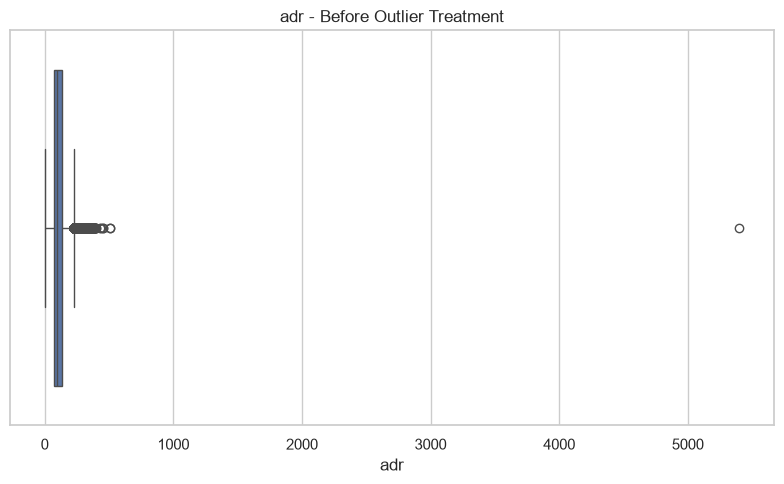

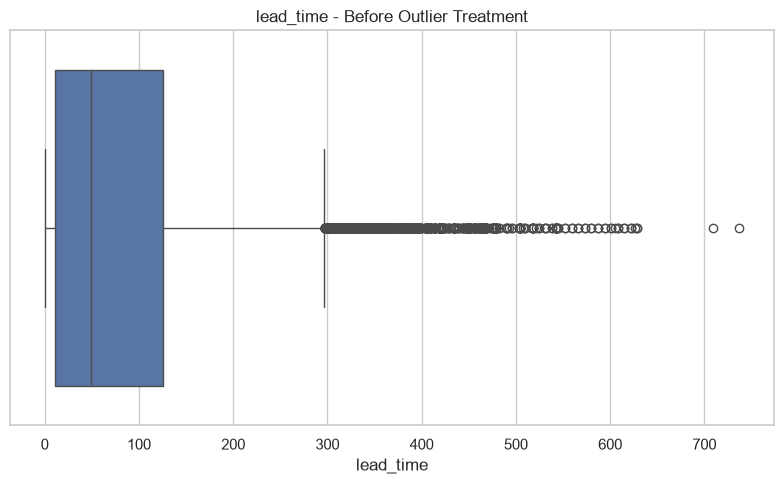

In [49]:
plot_boxplot("adr")
plot_boxplot("lead_time")

## Detect Outliers Using IQR

In [50]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"\nColumn : {column}")
    print(f"Lower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Outliers : {len(outliers)}")

    return outliers

In [51]:
for column in outlier_columns:
    detect_outliers_iqr(df_clean, column)


Column : lead_time
Lower Bound : -160.00
Upper Bound : 296.00
Outliers : 2394

Column : adr
Lower Bound : -20.52
Upper Bound : 226.88
Outliers : 2508

Column : stays_in_weekend_nights
Lower Bound : -3.00
Upper Bound : 5.00
Outliers : 213

Column : stays_in_week_nights
Lower Bound : -3.50
Upper Bound : 8.50
Outliers : 1514

Column : adults
Lower Bound : 2.00
Upper Bound : 2.00
Outliers : 22732

Column : children
Lower Bound : 0.00
Upper Bound : 0.00
Outliers : 8364

Column : babies
Lower Bound : 0.00
Upper Bound : 0.00
Outliers : 914

Column : previous_cancellations
Lower Bound : 0.00
Upper Bound : 0.00
Outliers : 1681

Column : booking_changes
Lower Bound : 0.00
Upper Bound : 0.00
Outliers : 15804


## Detect Outliers Using Z-Score

In [52]:
from scipy.stats import zscore

def detect_outliers_zscore(data, column):

    z_scores = np.abs(zscore(data[column]))

    outliers = data[z_scores > 3]

    print(f"{column} : {len(outliers)} outliers")

    return outliers

In [53]:
for column in outlier_columns:
    detect_outliers_zscore(df_clean, column)

lead_time : 1048 outliers
adr : 628 outliers
stays_in_weekend_nights : 281 outliers
stays_in_week_nights : 1514 outliers
adults : 295 outliers
children : 3669 outliers
babies : 914 outliers
previous_cancellations : 276 outliers
booking_changes : 1454 outliers


## Compare IQR and Z-Score

In [54]:
summary = []

for column in outlier_columns:

    # IQR
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_count = len(
        df_clean[
            (df_clean[column] < lower) |
            (df_clean[column] > upper)
        ]
    )

    # Z-score
    z = np.abs(zscore(df_clean[column]))

    z_count = (z > 3).sum()

    summary.append([
        column,
        iqr_count,
        z_count
    ])

comparison = pd.DataFrame(
    summary,
    columns=[
        "Feature",
        "IQR Outliers",
        "Z-Score Outliers"
    ]
)

comparison

,Feature,IQR Outliers,Z-Score Outliers
0,lead_time,2394,1048
1,adr,2508,628
2,stays_in_weekend_nights,213,281
3,stays_in_week_nights,1514,1514
4,adults,22732,295
5,children,8364,3669
6,babies,914,914
7,previous_cancellations,1681,276
8,booking_changes,15804,1454


## Treatment Strategy

In [55]:
def cap_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[column] = data[column].clip(
        lower,
        upper
    )

    return data

In [56]:
for column in outlier_columns:
    df_clean = cap_outliers(df_clean, column)

In [57]:
cap_outliers(df_clean, "lead_time")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,False,7,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Direct,Direct,False,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,False,13,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,False,14,2015,July,27,1,0,2.0,2,0.0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87220,City Hotel,False,23,2017,August,35,30,2,5.0,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,False,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
87221,City Hotel,False,102,2017,August,35,31,2,5.0,2,0.0,0,BB,FRA,Online TA,TA/TO,False,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
87222,City Hotel,False,34,2017,August,35,31,2,5.0,2,0.0,0,BB,DEU,Online TA,TA/TO,False,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
87223,City Hotel,False,109,2017,August,35,31,2,5.0,2,0.0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


## Verify Treatment

In [58]:
def plot_boxplot_after(column):

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=df_clean[column]
    )

    plt.title(f"{column} - After Outlier Treatment")

    plt.tight_layout()

    plt.savefig(
        f"../figures/phase_02/{column}_box_after.png",
        dpi=300
    )

    plt.show()

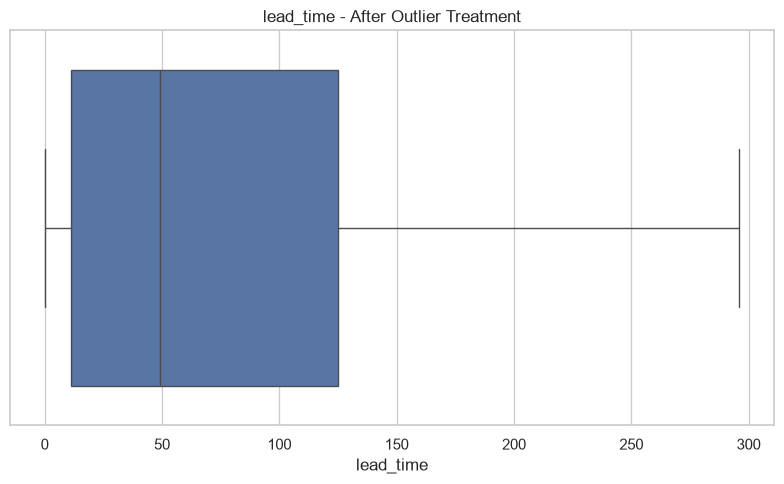

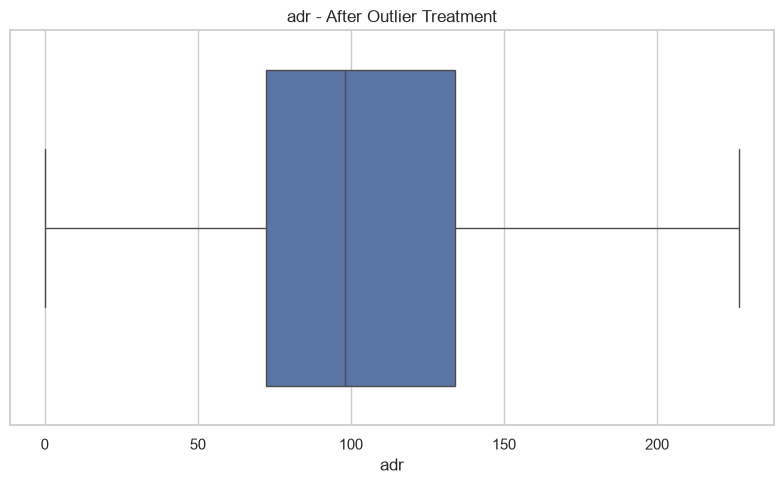

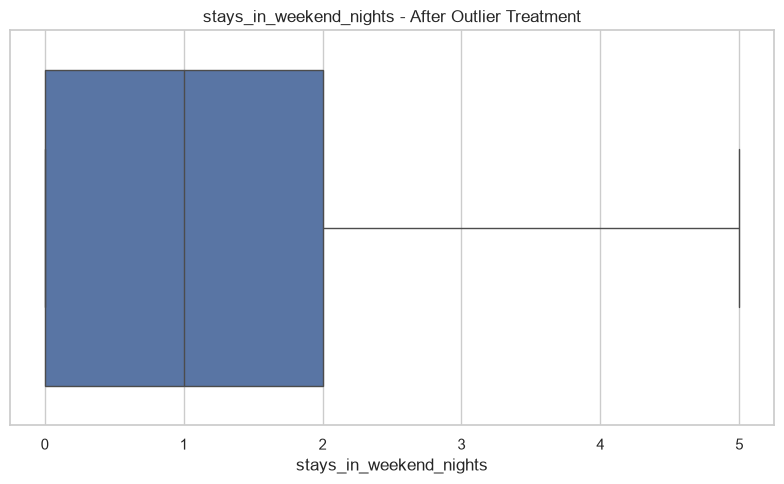

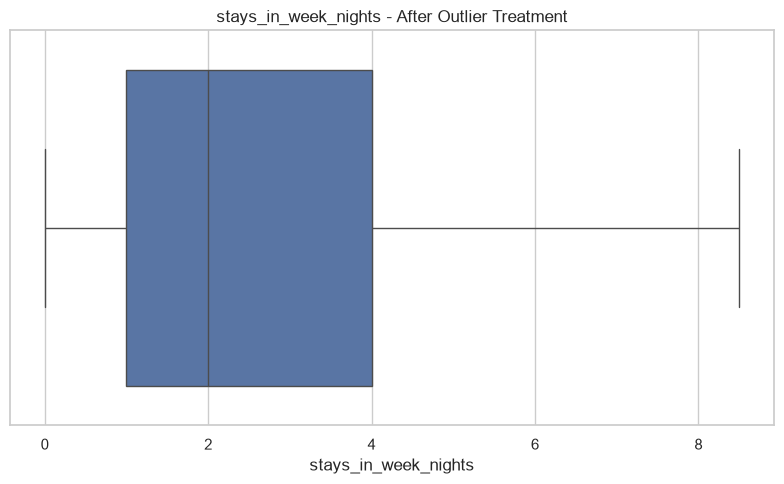

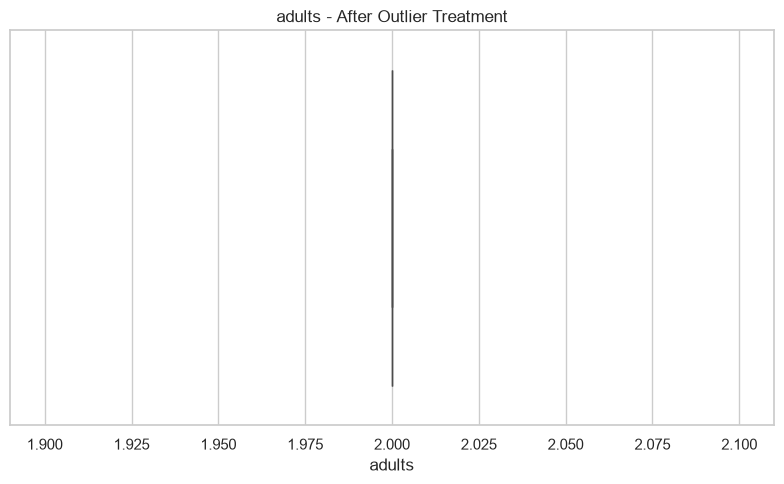

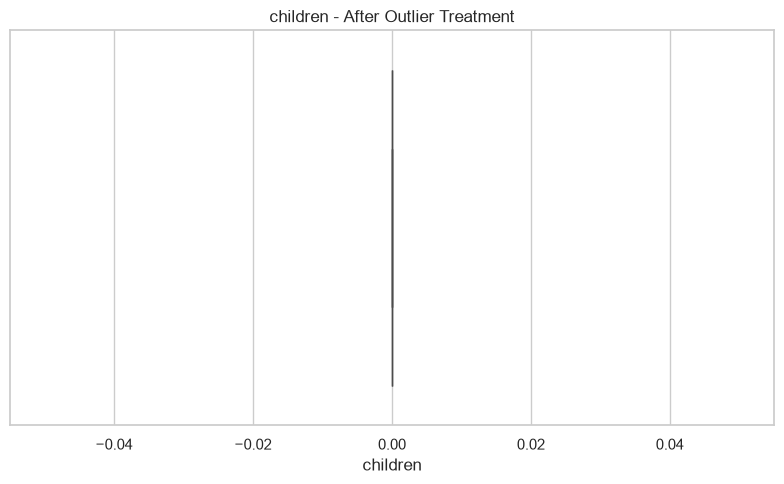

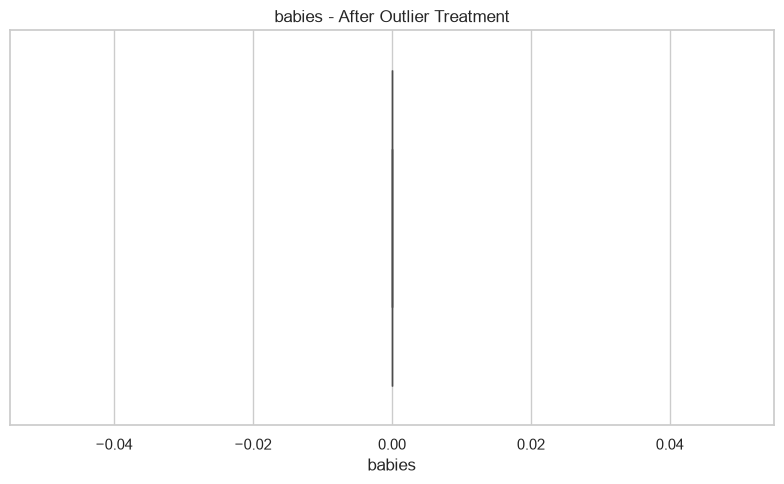

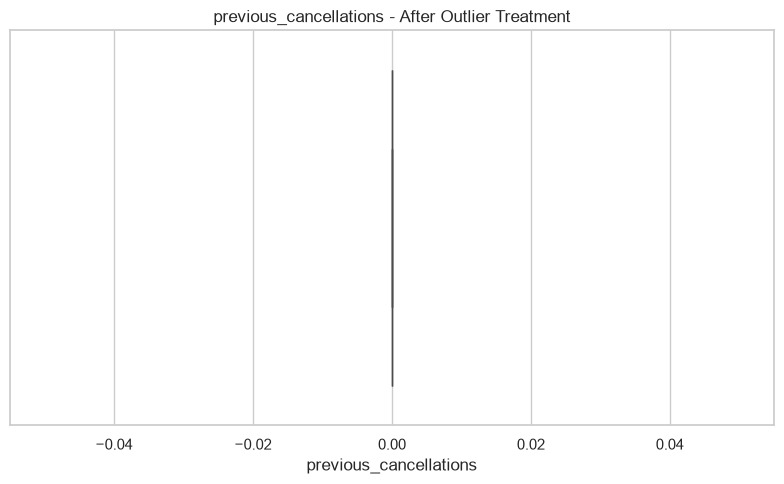

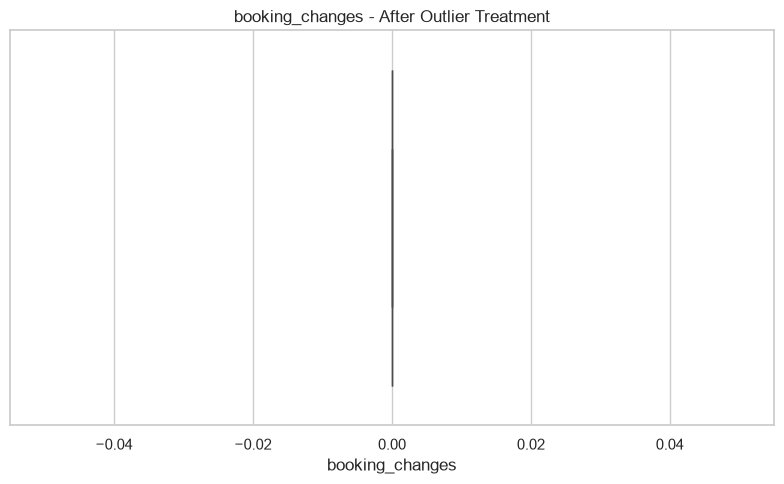

In [59]:
for column in outlier_columns:
    plot_boxplot_after(column)

## Save the Cleaned Dataset

In [60]:
df_clean.to_csv(
    "../data/processed/cleaned_hotel_bookings.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Summary

In [61]:
summary = pd.DataFrame({
    "Cleaning Step":[
        "Missing Values",
        "Duplicate Records",
        "Data Types",
        "Invalid Values",
        "Outlier Treatment"
    ],
    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

summary

,Cleaning Step,Status
0,Missing Values,Completed
1,Duplicate Records,Completed
2,Data Types,Completed
3,Invalid Values,Completed
4,Outlier Treatment,Completed


## Conclusion

#### Outliers were identified using both the IQR and Z-Score methods. After comparing the results and considering the business context, extreme values were treated using the IQR capping (winsorization) technique rather than deleting records. This approach minimizes the influence of extreme observations while preserving valuable booking information. The dataset is now cleaned, logically consistent, and ready for the transformation and feature engineering stages.

# Data Transformation

In [62]:
df_transform = df_clean.copy()

print("Working copy for data transformation created successfully.")

Working copy for data transformation created successfully.


# Label Encoding

### Before Encoding

In [63]:
# Check unique values
print(df_transform["hotel"].value_counts())

hotel
City Hotel      53270
Resort Hotel    33955
Name: count, dtype: int64


### Import LabelEncoder

In [64]:
from sklearn.preprocessing import LabelEncoder

### Create Encoder

In [65]:
label_encoder = LabelEncoder()

### Encode the hotel Column

In [66]:
df_transform["hotel_label"] = label_encoder.fit_transform(df_transform["hotel"])

df_transform[["hotel", "hotel_label"]].head()

,hotel,hotel_label
0,Resort Hotel,1
1,Resort Hotel,1
2,Resort Hotel,1
3,Resort Hotel,1
4,Resort Hotel,1


### Mapping

In [67]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print(mapping)

{'City Hotel': np.int64(0), 'Resort Hotel': np.int64(1)}


### Before vs After

In [68]:
comparison = df_transform[["hotel", "hotel_label"]].head(10)

comparison

,hotel,hotel_label
0,Resort Hotel,1
1,Resort Hotel,1
2,Resort Hotel,1
3,Resort Hotel,1
4,Resort Hotel,1
5,Resort Hotel,1
6,Resort Hotel,1
7,Resort Hotel,1
8,Resort Hotel,1
9,Resort Hotel,1


### Visualization

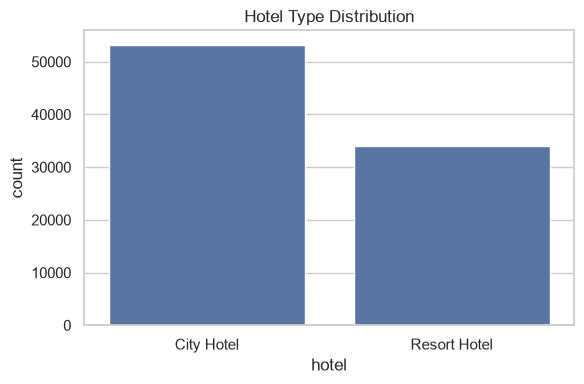

In [69]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_transform, x="hotel")

plt.title("Hotel Type Distribution")

plt.tight_layout()

plt.savefig("../figures/phase_02/hotel_label_encoding_before.png",
            dpi=300)

plt.show()

## Conclusion

#### The binary categorical feature hotel was transformed using Label Encoding. A new column hotel_label was created to preserve the original data for comparison. Label Encoding is appropriate here because the feature contains only two categories. The encoded values facilitate numerical analysis while maintaining the original semantic meaning.

# One-Hot Encoding

## Inspect Categories

In [70]:
columns_to_encode = [
    "meal",
    "market_segment",
    "distribution_channel",
    "customer_type"
]

for column in columns_to_encode:
    print(f"\n{column}")
    print(df_transform[column].value_counts())


meal
meal
BB           67902
SC            9391
HB            9080
Undefined      492
FB             360
Name: count, dtype: int64

market_segment
market_segment
Online TA        51552
Offline TA/TO    13855
Direct           11779
Groups            4921
Corporate         4200
Complementary      692
Aviation           226
Undefined            0
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO        69028
Direct       12953
Corporate     5062
GDS            181
Undefined        1
Name: count, dtype: int64

customer_type
customer_type
Transient          71862
Transient-Party    11687
Contract            3135
Group                541
Name: count, dtype: int64


## Apply One-Hot Encoding

In [71]:
one_hot_df = pd.get_dummies(
    df_transform[columns_to_encode],
    prefix=columns_to_encode,
    drop_first=False,
    dtype=int
)

print("One-Hot Encoding completed successfully.")

One-Hot Encoding completed successfully.


## Preview Encoded Columns

In [72]:
one_hot_df.head()

,meal_BB,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
2,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
3,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0


## Check Shape

In [73]:
print("Original Shape :", df_transform.shape)
print("Encoded Shape  :", one_hot_df.shape)

Original Shape : (87225, 33)
Encoded Shape  : (87225, 22)


## Combine with Original Dataset

In [74]:
df_onehot_demo = pd.concat(
    [df_transform, one_hot_df],
    axis=1
)

df_onehot_demo.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,hotel_label,meal_BB,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
1,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
2,Resort Hotel,False,7,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Direct,Direct,False,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
3,Resort Hotel,False,13,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,Resort Hotel,False,14,2015,July,27,1,0,2.0,2,0.0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0


## Compare Before & After

In [75]:
comparison = pd.concat(
    [
        df_transform[columns_to_encode].head(),
        one_hot_df.head()
    ],
    axis=1
)

comparison

,meal,market_segment,distribution_channel,customer_type,meal_BB,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,BB,Direct,Direct,Transient,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
1,BB,Direct,Direct,Transient,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
2,BB,Direct,Direct,Transient,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0
3,BB,Corporate,Corporate,Transient,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,BB,Online TA,TA/TO,Transient,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0


## Visual Verification

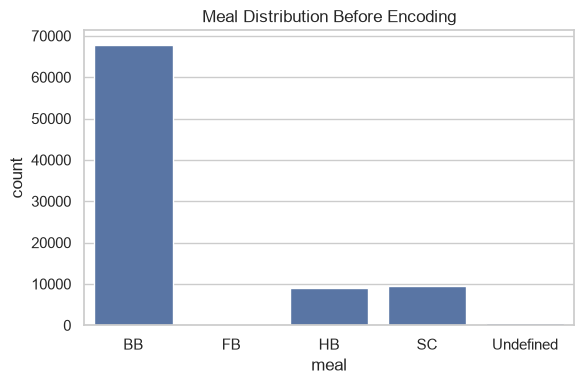

In [76]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_transform,
    x="meal"
)

plt.title("Meal Distribution Before Encoding")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/meal_before_onehot.png",
    dpi=300
)

plt.show()

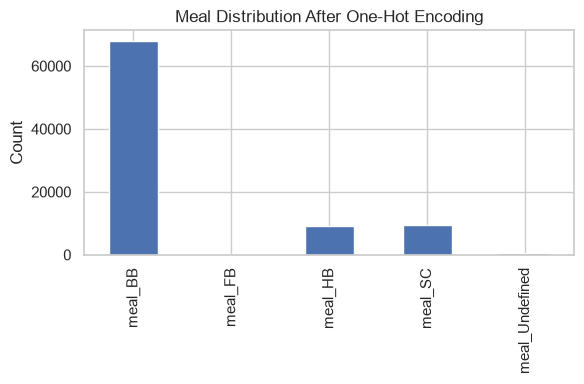

In [77]:
meal_columns = [col for col in one_hot_df.columns if col.startswith("meal_")]

one_hot_df[meal_columns].sum().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Meal Distribution After One-Hot Encoding")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/meal_after_onehot.png",
    dpi=300
)

plt.show()

In [78]:
print(
    "Unique Countries:",
    df_transform["country"].nunique()
)

Unique Countries: 177


## Conclusion

#### One-Hot Encoding was applied to selected nominal categorical features with a manageable number of categories (meal, market_segment, distribution_channel, and customer_type). High-cardinality features such as country were intentionally excluded to avoid generating an excessive number of columns. The encoded features accurately preserve category information without introducing artificial ordering.

# Normalization (Min-Max Scaling)

## Import MinMaxScaler

In [79]:
scaling_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies"
]

In [80]:
from sklearn.preprocessing import MinMaxScaler

## Create a Working Copy

In [81]:
df_normalized = df_transform.copy()

## Check Original Statistics

In [82]:
df_normalized[scaling_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,87225.0,78.444918,81.052481,0.0,11.00,49.0,125.0,296.000
adr,87225.0,105.524569,49.032923,0.0,72.25,98.2,134.1,226.875
stays_in_weekend_nights,87225.0,0.998899,0.993097,0.0,0.00,1.0,2.0,5.000
stays_in_week_nights,87225.0,2.577048,1.804803,0.0,1.00,2.0,4.0,8.500
adults,87225.0,2.000000,0.000000,2.0,2.00,2.0,2.0,2.000
children,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000
babies,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000


## Create Scaler

In [83]:
scaler = MinMaxScaler()

## Apply Normalization

In [84]:
df_normalized[scaling_columns] = scaler.fit_transform(
    df_normalized[scaling_columns]
)

## Verify Results

In [85]:
df_normalized[scaling_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,87225.0,0.265017,0.273826,0.0,0.037162,0.165541,0.422297,1.0
adr,87225.0,0.465122,0.216123,0.0,0.318457,0.432837,0.591074,1.0
stays_in_weekend_nights,87225.0,0.199780,0.198619,0.0,0.000000,0.200000,0.400000,1.0
stays_in_week_nights,87225.0,0.303182,0.212330,0.0,0.117647,0.235294,0.470588,1.0
adults,87225.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
children,87225.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
babies,87225.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0


## Compare Before & After

In [86]:
comparison = pd.DataFrame({
    "Original ADR": df_transform["adr"].head(10),
    "Normalized ADR": df_normalized["adr"].head(10)
})

comparison

,Original ADR,Normalized ADR
0,0.0,0.000000
1,0.0,0.000000
2,75.0,0.330579
3,75.0,0.330579
4,98.0,0.431956
5,107.0,0.471625
6,103.0,0.453994
7,82.0,0.361433
8,105.5,0.465014
9,123.0,0.542149


## Distribution Comparison

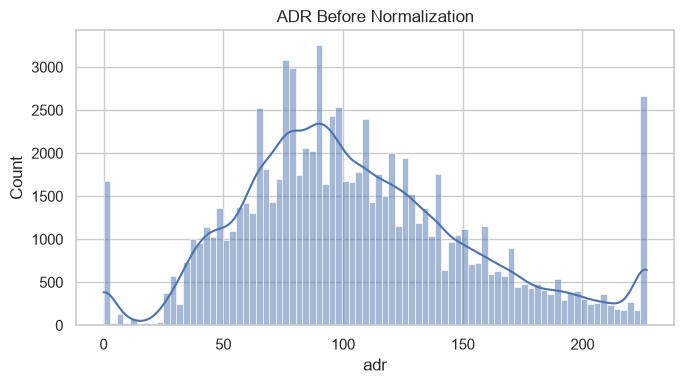

In [87]:
# Before

plt.figure(figsize=(7,4))

sns.histplot(
    df_transform["adr"],
    kde=True
)

plt.title("ADR Before Normalization")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/adr_before_normalization.png",
    dpi=300
)

plt.show()

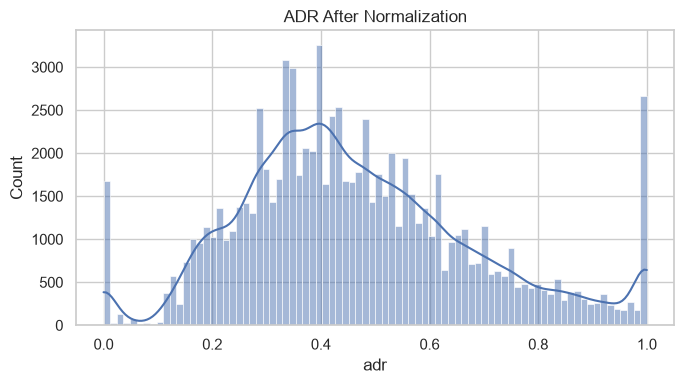

In [88]:
# After

plt.figure(figsize=(7,4))

sns.histplot(
    df_normalized["adr"],
    kde=True
)

plt.title("ADR After Normalization")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/adr_after_normalization.png",
    dpi=300
)

plt.show()

## Box Plot Comparison

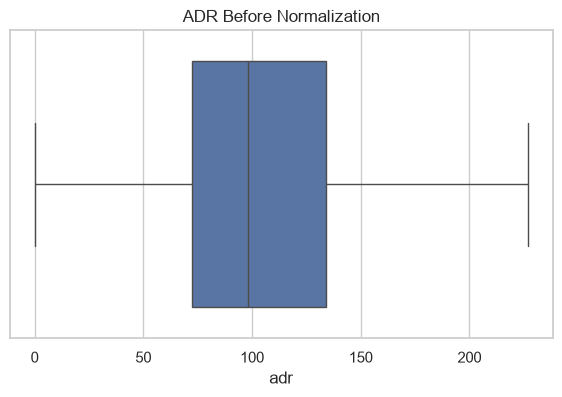

In [89]:
# Before

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_transform["adr"]
)

plt.title("ADR Before Normalization")

plt.show()

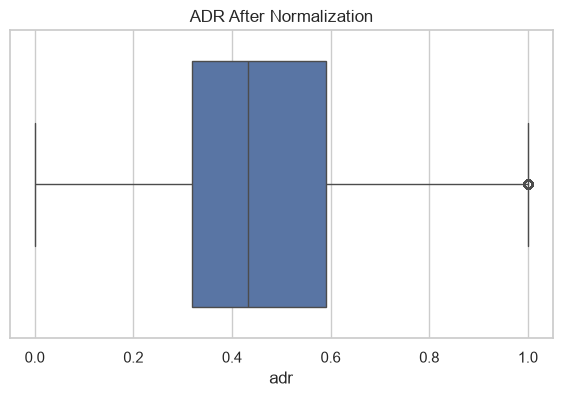

In [90]:
# After

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_normalized["adr"]
)

plt.title("ADR After Normalization")

plt.show()

# Summary Table

In [91]:
summary = pd.DataFrame({
    "Feature": scaling_columns,
    "Minimum": df_normalized[scaling_columns].min().values,
    "Maximum": df_normalized[scaling_columns].max().values
})

summary

,Feature,Minimum,Maximum
0,lead_time,0.0,1.0
1,adr,0.0,1.0
2,stays_in_weekend_nights,0.0,1.0
3,stays_in_week_nights,0.0,1.0
4,adults,0.0,0.0
5,children,0.0,0.0
6,babies,0.0,0.0


## Conclusion:

#### Min-Max Normalization was applied to selected continuous numerical features to scale their values between 0 and 1. The transformation preserves the relative relationships among observations while bringing all features onto a common scale. This technique is especially useful for distance-based algorithms and when variables with different units need to be compared.

# Standardization (Z-Score Scaling)

## Import StandardScaler

In [92]:
from sklearn.preprocessing import StandardScaler

## Create a Working Copy

In [93]:
df_standardized = df_transform.copy()

## Select Numerical Columns

In [94]:
scaling_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies"
]

## Check Original Statistics

In [95]:
df_standardized[scaling_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,87225.0,78.444918,81.052481,0.0,11.00,49.0,125.0,296.000
adr,87225.0,105.524569,49.032923,0.0,72.25,98.2,134.1,226.875
stays_in_weekend_nights,87225.0,0.998899,0.993097,0.0,0.00,1.0,2.0,5.000
stays_in_week_nights,87225.0,2.577048,1.804803,0.0,1.00,2.0,4.0,8.500
adults,87225.0,2.000000,0.000000,2.0,2.00,2.0,2.0,2.000
children,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000
babies,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000


## Create StandardScaler

In [96]:
scaler = StandardScaler()

## Apply Standardization

In [97]:
df_standardized[scaling_columns] = scaler.fit_transform(
    df_standardized[scaling_columns]
)

# Verify the Results

In [98]:
df_standardized[scaling_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,87225.0,-5.734848e-17,1.000006,-0.967834,-0.832119,-0.363284,0.574385,2.684142
adr,87225.0,-3.023829e-16,1.000006,-2.152129,-0.678621,-0.149381,0.582784,2.474891
stays_in_weekend_nights,87225.0,-3.128099e-17,1.000006,-1.005849,-1.005849,0.001108,1.008065,4.028936
stays_in_week_nights,87225.0,1.042700e-16,1.000006,-1.427891,-0.873811,-0.319731,0.788430,3.281791
adults,87225.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
children,87225.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
babies,87225.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [99]:
# Explicit Verification

summary = pd.DataFrame({
    "Mean": df_standardized[scaling_columns].mean(),
    "Standard Deviation": df_standardized[scaling_columns].std()
})

summary

,Mean,Standard Deviation
lead_time,-5.734848e-17,1.000006
adr,-3.023829e-16,1.000006
stays_in_weekend_nights,-3.128099e-17,1.000006
stays_in_week_nights,1.042700e-16,1.000006
adults,0.000000e+00,0.000000
children,0.000000e+00,0.000000
babies,0.000000e+00,0.000000


## Compare Before & After

In [100]:
comparison = pd.DataFrame({
    "Original ADR": df_transform["adr"].head(10),
    "Standardized ADR": df_standardized["adr"].head(10)
})

comparison

,Original ADR,Standardized ADR
0,0.0,-2.152129
1,0.0,-2.152129
2,75.0,-0.622536
3,75.0,-0.622536
4,98.0,-0.153460
5,107.0,0.030091
6,103.0,-0.051488
7,82.0,-0.479774
8,105.5,-0.000501
9,123.0,0.356404


## Distribution Comparison

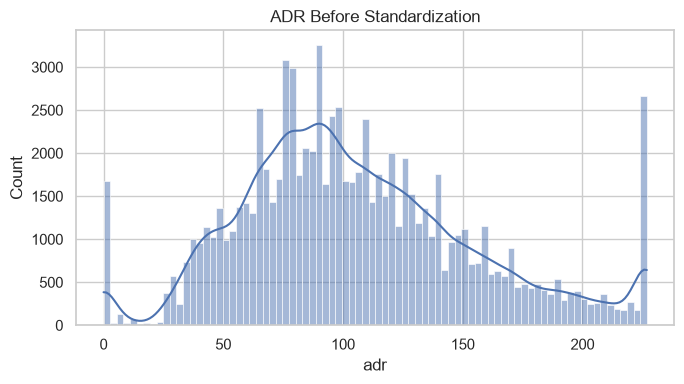

In [101]:
# Before Standardization

plt.figure(figsize=(7,4))

sns.histplot(
    df_transform["adr"],
    kde=True
)

plt.title("ADR Before Standardization")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/adr_before_standardization.png",
    dpi=300
)

plt.show()

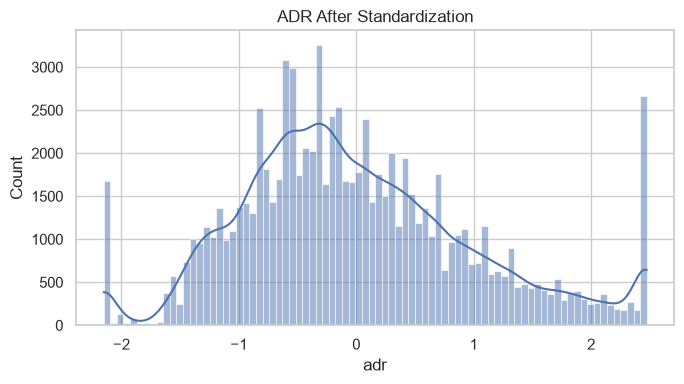

In [102]:
# After Standardization

plt.figure(figsize=(7,4))

sns.histplot(
    df_standardized["adr"],
    kde=True
)

plt.title("ADR After Standardization")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/adr_after_standardization.png",
    dpi=300
)

plt.show()

## Box Plot Comparison

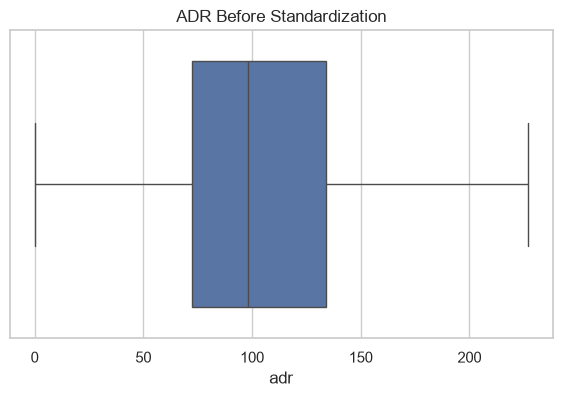

In [103]:
# Before

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_transform["adr"]
)

plt.title("ADR Before Standardization")

plt.show()

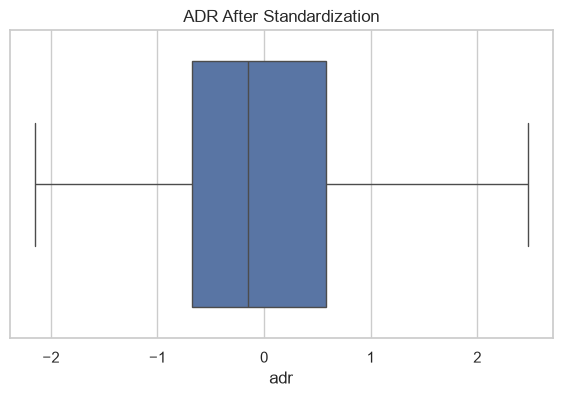

In [104]:
# After

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_standardized["adr"]
)

plt.title("ADR After Standardization")

plt.show()

## Compare Normalization vs Standardization

In [105]:
comparison = pd.DataFrame({
    "Original ADR": df_transform["adr"].head(10),
    "Normalized ADR": df_normalized["adr"].head(10),
    "Standardized ADR": df_standardized["adr"].head(10)
})

comparison

,Original ADR,Normalized ADR,Standardized ADR
0,0.0,0.000000,-2.152129
1,0.0,0.000000,-2.152129
2,75.0,0.330579,-0.622536
3,75.0,0.330579,-0.622536
4,98.0,0.431956,-0.153460
5,107.0,0.471625,0.030091
6,103.0,0.453994,-0.051488
7,82.0,0.361433,-0.479774
8,105.5,0.465014,-0.000501
9,123.0,0.542149,0.356404


## Conclusion

#### Standardization was applied to selected numerical features using the Z-Score method. After transformation, the features have an approximate mean of 0 and a standard deviation of 1, while preserving the underlying distribution. Standardization is particularly suitable for statistical modeling and algorithms that assume normally distributed input features.

# Log Transformation

## Create a Working Copy

In [106]:
df_log = df_transform.copy()

## Calculate Skewness

In [107]:
numerical_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes"
]

skewness = df_log[numerical_columns].skew()

skewness.sort_values(ascending=False)

lead_time                  1.099105
stays_in_week_nights       1.006329
stays_in_weekend_nights    0.764456
adr                        0.514105
adults                     0.000000
children                   0.000000
babies                     0.000000
previous_cancellations     0.000000
booking_changes            0.000000
dtype: float64

## Select Highly Skewed Features

In [108]:
highly_skewed = skewness[skewness > 1]

print(highly_skewed)

lead_time               1.099105
stays_in_week_nights    1.006329
dtype: float64


## Visualize Before Transformation

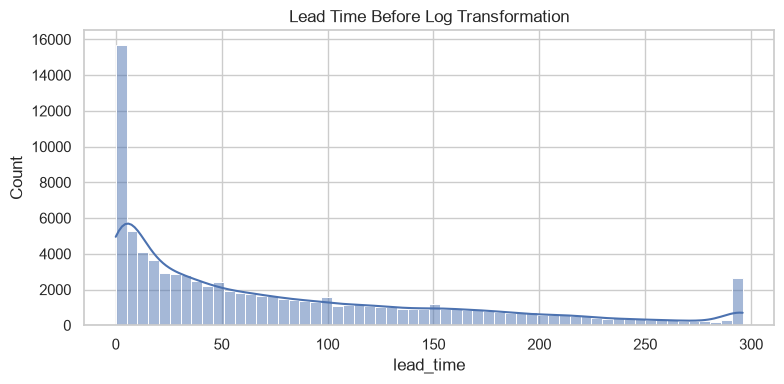

In [109]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_log["lead_time"],
    kde=True
)

plt.title("Lead Time Before Log Transformation")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/lead_time_before_log.png",
    dpi=300
)

plt.show()

## Apply Log Transformation

In [110]:
for column in highly_skewed.index:
    df_log[column] = np.log1p(df_log[column])

print("Log Transformation Applied Successfully.")

Log Transformation Applied Successfully.


## Compare Before & After

In [111]:
comparison = pd.DataFrame({
    "Original Lead Time": df_transform["lead_time"].head(10),
    "Log Transformed Lead Time": df_log["lead_time"].head(10)
})

comparison

,Original Lead Time,Log Transformed Lead Time
0,296,5.693732
1,296,5.693732
2,7,2.079442
3,13,2.639057
4,14,2.708050
5,0,0.000000
6,9,2.302585
7,85,4.454347
8,75,4.330733
9,23,3.178054


## Visualize After Transformation

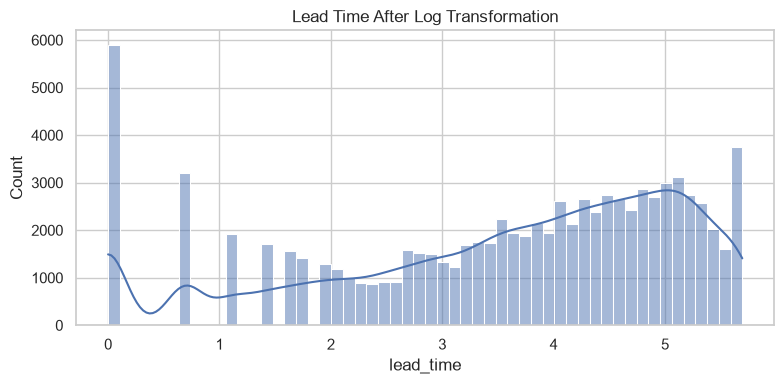

In [112]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_log["lead_time"],
    kde=True
)

plt.title("Lead Time After Log Transformation")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/lead_time_after_log.png",
    dpi=300
)

plt.show()

## Compare Skewness

In [113]:
skewness_before = df_transform[numerical_columns].skew()

skewness_after = df_log[numerical_columns].skew()

comparison = pd.DataFrame({
    "Before": skewness_before,
    "After": skewness_after
})

comparison

,Before,After
lead_time,1.099105,-0.734010
adr,0.514105,0.514105
stays_in_weekend_nights,0.764456,0.764456
stays_in_week_nights,1.006329,-0.283753
adults,0.000000,0.000000
children,0.000000,0.000000
babies,0.000000,0.000000
previous_cancellations,0.000000,0.000000
booking_changes,0.000000,0.000000


## Box Plot Comparison

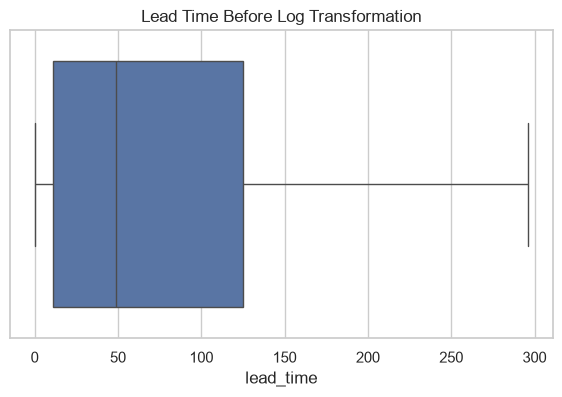

In [114]:
# Before

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_transform["lead_time"]
)

plt.title("Lead Time Before Log Transformation")

plt.show()

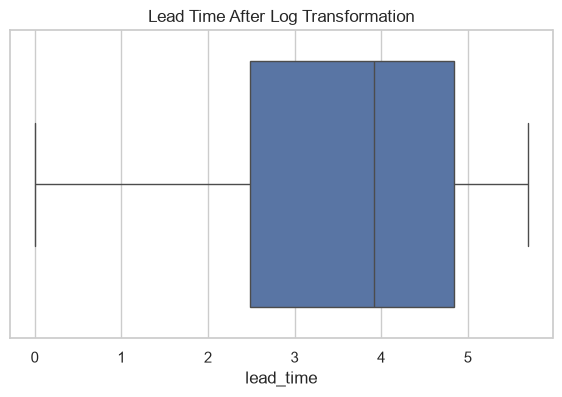

In [115]:
# After

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_log["lead_time"]
)

plt.title("Lead Time After Log Transformation")

plt.show()

## Summary Table

In [116]:
summary = pd.DataFrame({
    "Feature": highly_skewed.index,
    "Skewness Before": skewness_before[highly_skewed.index].values,
    "Skewness After": skewness_after[highly_skewed.index].values
})

summary

,Feature,Skewness Before,Skewness After
0,lead_time,1.099105,-0.734010
1,stays_in_week_nights,1.006329,-0.283753


## Conclusion

### Log Transformation was applied only to numerical features exhibiting high positive skewness. The np.log1p() function was used to safely transform features containing zero values. Comparison of skewness values and distribution plots confirmed that the transformation reduced skewness while preserving the relative ordering of observations. This results in distributions that are closer to normality, making them more suitable for statistical analysis.

# Box-Cox Transformation

## Import PowerTransformer

In [117]:
from sklearn.preprocessing import PowerTransformer

## Create Working Copy

In [118]:
df_boxcox = df_transform.copy()

## Select Candidate Columns

In [119]:
boxcox_columns = [
    "lead_time",
    "adr",
    "previous_cancellations",
    "booking_changes"
]

## Check Minimum Values

In [120]:
df_boxcox[boxcox_columns].min()

lead_time                 0.0
adr                       0.0
previous_cancellations    0.0
booking_changes           0.0
dtype: float64

## Handle Zero Values

In [121]:
for column in boxcox_columns:
    df_boxcox[column] = df_boxcox[column] + 1

In [122]:
df_boxcox[boxcox_columns].min()

lead_time                 1.0
adr                       1.0
previous_cancellations    1.0
booking_changes           1.0
dtype: float64

## Calculate Skewness Before Transformation

In [123]:
skew_before = df_boxcox[boxcox_columns].skew()

skew_before

lead_time                 1.099105
adr                       0.514105
previous_cancellations    0.000000
booking_changes           0.000000
dtype: float64

## Create Box-Cox Transformer

In [124]:
boxcox = PowerTransformer(
    method="box-cox",
    standardize=False
)

## Apply Box-Cox Transformation

In [125]:
# 1. Find columns that are constant
constant_cols = [col for col in boxcox_columns if df_boxcox[col].nunique() <= 1]

# 2. Keep only the columns that actually have variation
valid_cols = [col for col in boxcox_columns if col not in constant_cols]

# 3. Transform only the valid columns
if valid_cols:
    df_boxcox[valid_cols] = boxcox.fit_transform(df_boxcox[valid_cols])
else:
    print("No valid non-constant columns found to transform!")

## Calculate Skewness After Transformation

In [126]:
skew_after = df_boxcox[boxcox_columns].skew()

skew_after

lead_time                -0.154033
adr                       0.011255
previous_cancellations    0.000000
booking_changes           0.000000
dtype: float64

## Compare Before & After

In [127]:
comparison = pd.DataFrame({
    "Before": skew_before,
    "After": skew_after
})

comparison

,Before,After
lead_time,1.099105,-0.154033
adr,0.514105,0.011255
previous_cancellations,0.000000,0.000000
booking_changes,0.000000,0.000000


## Distribution Comparison

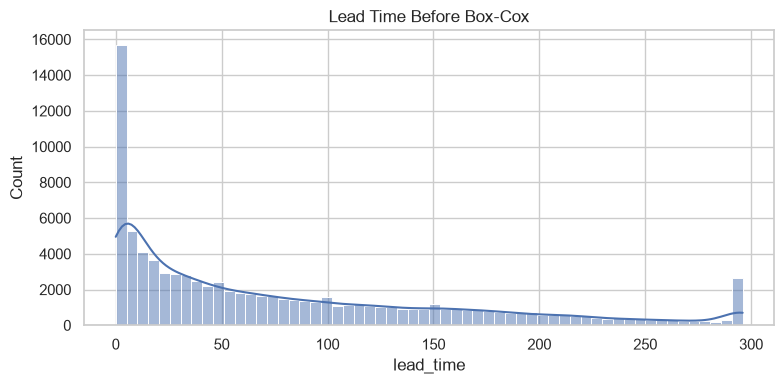

In [128]:
# Before

plt.figure(figsize=(8,4))

sns.histplot(
    df_transform["lead_time"],
    kde=True
)

plt.title("Lead Time Before Box-Cox")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/lead_time_before_boxcox.png",
    dpi=300
)

plt.show()

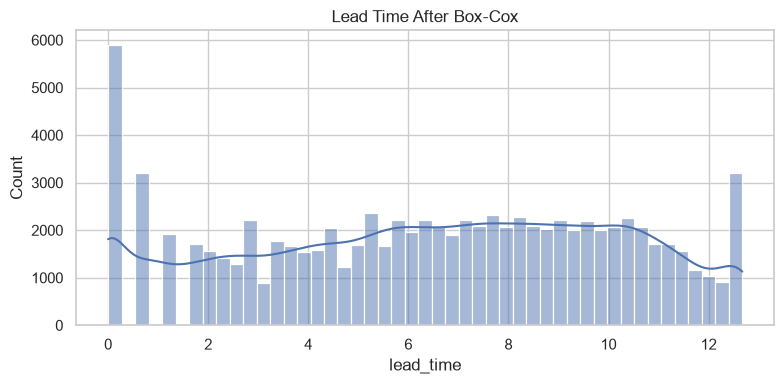

In [129]:
# After

plt.figure(figsize=(8,4))

sns.histplot(
    df_boxcox["lead_time"],
    kde=True
)

plt.title("Lead Time After Box-Cox")

plt.tight_layout()

plt.savefig(
    "../figures/phase_02/lead_time_after_boxcox.png",
    dpi=300
)

plt.show()

## Box Plot Comparison

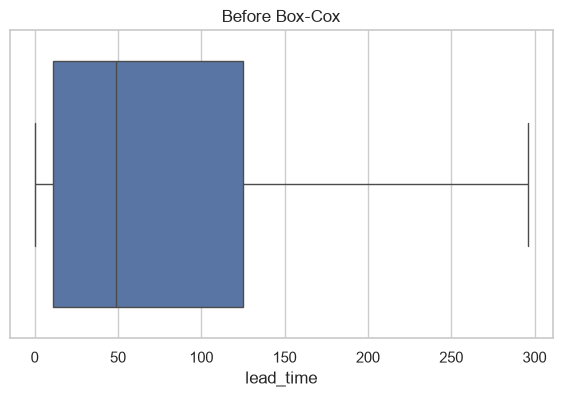

In [130]:
# Before

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_transform["lead_time"]
)

plt.title("Before Box-Cox")

plt.show()

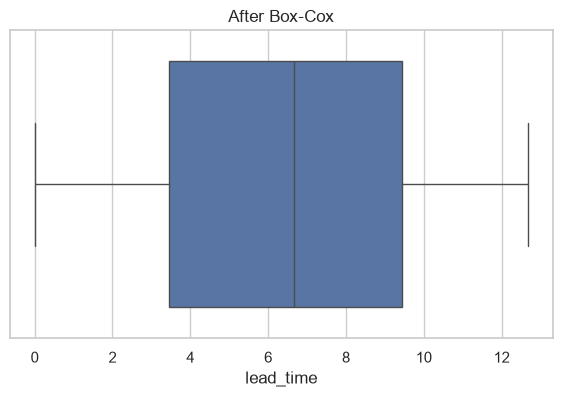

In [131]:
# After

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_boxcox["lead_time"]
)

plt.title("After Box-Cox")

plt.show()

## Summary Table

In [132]:
boxcox_summary = pd.DataFrame({
    "Feature": boxcox_columns,
    "Skewness Before": skew_before.values,
    "Skewness After": skew_after.values
})

boxcox_summary

,Feature,Skewness Before,Skewness After
0,lead_time,1.099105,-0.154033
1,adr,0.514105,0.011255
2,previous_cancellations,0.000000,0.000000
3,booking_changes,0.000000,0.000000


## Save the Transformation Dataset

In [133]:
df_transform.to_csv(
    "../data/processed/transformed_hotel_bookings.csv",
    index=False
)

print("Transformed dataset saved successfully.")

Transformed dataset saved successfully.


## Conclusion

#### The Box-Cox Transformation was applied to selected positively skewed numerical features after ensuring all values were strictly positive. The transformation automatically determined the optimal power parameter for each feature, resulting in distributions that are closer to normal. Comparison of skewness values and distribution plots confirmed that Box-Cox generally reduced skewness more effectively than the Log Transformation.

# Feature Engineering

In [134]:
df_final = df_transform.copy()

print("Feature Engineering Dataset Created Successfully.")

Feature Engineering Dataset Created Successfully.


## Total Stay Duration

In [135]:
df_final["total_stay_duration"] = (
    df_final["stays_in_week_nights"] +
    df_final["stays_in_weekend_nights"]
)

In [136]:
# Verify

df_final[
[
"stays_in_week_nights",
"stays_in_weekend_nights",
"total_stay_duration"
]
].head()

,stays_in_week_nights,stays_in_weekend_nights,total_stay_duration
0,0.0,0,0.0
1,0.0,0,0.0
2,1.0,0,1.0
3,1.0,0,1.0
4,2.0,0,2.0


In [137]:
# Statistics

df_final["total_stay_duration"].describe()

count    87225.000000
mean         3.575947
std          2.448157
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         13.500000
Name: total_stay_duration, dtype: float64

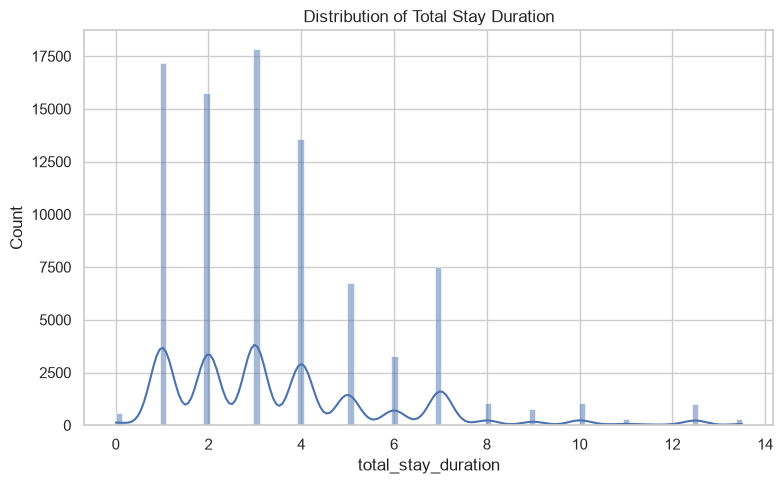

In [138]:
# Visualization

plt.figure(figsize=(8,5))

sns.histplot(
    df_final["total_stay_duration"],
    kde=True
)

plt.title("Distribution of Total Stay Duration")

plt.tight_layout()

plt.savefig(
"../figures/phase_02/total_stay_duration.png",
dpi=300
)

plt.show()

## Total Guests

In [139]:
df_final["total_guests"] = (
    df_final["adults"] +
    df_final["children"] +
    df_final["babies"]
)

In [140]:
# Verify

df_final[
[
"adults",
"children",
"babies",
"total_guests"
]
].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,2,0.0,0,2.0
3,2,0.0,0,2.0
4,2,0.0,0,2.0


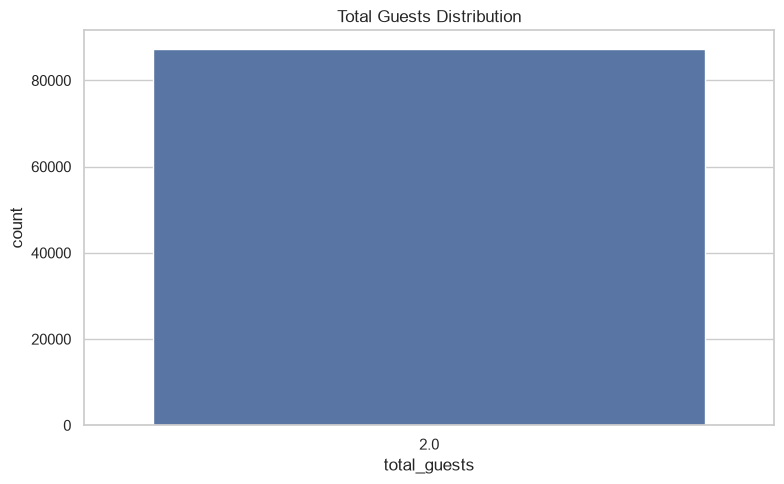

In [141]:
# Visualization
plt.figure(figsize=(8,5))

sns.countplot(
data=df_final,
x="total_guests"
)

plt.title("Total Guests Distribution")

plt.tight_layout()

plt.savefig(
"../figures/phase_02/total_guests.png",
dpi=300
)

plt.show()

# Booking Lead Time Category

In [142]:
bins = [-1,30,90,180,np.inf]

labels = [
"Short",
"Medium",
"Long",
"Very Long"
]

df_final["lead_time_category"] = pd.cut(
df_final["lead_time"],
bins=bins,
labels=labels
)

In [143]:
# Verify

df_final[
[
"lead_time",
"lead_time_category"
]
].head()

,lead_time,lead_time_category
0,296,Very Long
1,296,Very Long
2,7,Short
3,13,Short
4,14,Short


In [144]:
# Distribution

df_final["lead_time_category"].value_counts()

lead_time_category
Short        34525
Medium       22720
Long         18224
Very Long    11756
Name: count, dtype: int64

## Weekend vs Weekday Stay

In [145]:
df_final["stay_type"] = np.where(

df_final["stays_in_weekend_nights"] >
df_final["stays_in_week_nights"],

"Weekend",

"Weekday"

)

In [146]:
# Verify

df_final["stay_type"].value_counts()

stay_type
Weekday    77317
Weekend     9908
Name: count, dtype: int64

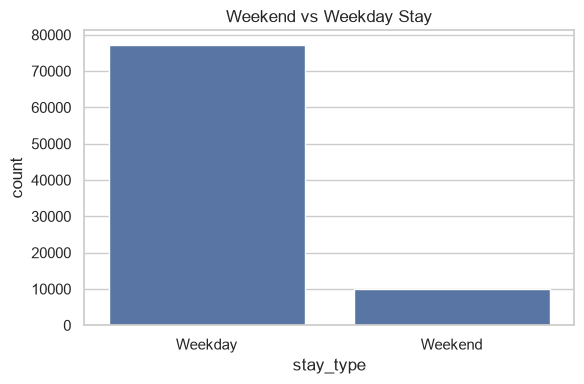

In [147]:
# Visualization

plt.figure(figsize=(6,4))

sns.countplot(
data=df_final,
x="stay_type"
)

plt.title("Weekend vs Weekday Stay")

plt.tight_layout()

plt.savefig(
"../figures/phase_02/stay_type.png",
dpi=300
)

plt.show()

## Booking Season

In [148]:
season_map = {

"January":"Winter",
"February":"Winter",

"March":"Spring",
"April":"Spring",
"May":"Spring",

"June":"Summer",
"July":"Summer",
"August":"Summer",

"September":"Autumn",
"October":"Autumn",
"November":"Autumn",

"December":"Winter"

}

df_final["booking_season"] = (
df_final["arrival_date_month"]
.map(season_map)
)

In [149]:
# Verify

df_final[
[
"arrival_date_month",
"booking_season"
]
].head()

,arrival_date_month,booking_season
0,July,Summer
1,July,Summer
2,July,Summer
3,July,Summer
4,July,Summer


In [150]:
# Distribution

df_final["booking_season"].value_counts()

booking_season
Summer    29037
Spring    23732
Autumn    18576
Winter    15880
Name: count, dtype: int64

## Average Daily Revenue

In [151]:
df_final = df_final.rename(
    columns={
        "adr": "average_daily_rate"
    }
)

## Customer Type Features

In [152]:
df_final["guest_status"] = np.where(
    df_final["is_repeated_guest"],
    "Returning",
    "New"
)

In [153]:
# Verify

df_final["guest_status"].value_counts()

guest_status
New          83862
Returning     3363
Name: count, dtype: int64

## Save Final Dataset

In [154]:
df_final.to_csv(
"../data/processed/final_hotel_bookings.csv",
index=False
)

print("Final dataset saved successfully.")

Final dataset saved successfully.


## Feature Engineering Summary

In [155]:
feature_summary = pd.DataFrame({
    "New Feature": [
        "total_stay_duration",
        "total_guests",
        "lead_time_category",
        "stay_type",
        "booking_season",
        "guest_status"
    ],
    "Purpose": [
        "Total nights stayed",
        "Total guests in booking",
        "Booking lead time classification",
        "Weekend vs weekday analysis",
        "Seasonal booking analysis",
        "Returning vs new guest analysis"
    ]
})

feature_summary

,New Feature,Purpose
0,total_stay_duration,Total nights stayed
1,total_guests,Total guests in booking
2,lead_time_category,Booking lead time classification
3,stay_type,Weekend vs weekday analysis
4,booking_season,Seasonal booking analysis
5,guest_status,Returning vs new guest analysis
